In [ ]:

# !pip install pandas numpy nltk scikit-learn gensim wordcloud matplotlib sentencepiece

In [1]:
import re
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from gensim.models import Word2Vec
from wordcloud import WordCloud, STOPWORDS

# NLTK resources (download once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
# Path to your CSV
CSV_PATH = "/content/drive/MyDrive/AI_Saturday/FreeText_NLP/scraped_quotes.csv"


In [3]:
#read file
df = pd.read_csv(CSV_PATH)

In [4]:
#remove newlines
# If Tags was saved as a Python list string, parse it back to a list
if 'Tags' in df.columns and df['Tags'].dtype == object:
    try:
        df['Tags'] = df['Tags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)
    except Exception:
        pass

def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = s.replace('\n', ' ').replace('\r', ' ')           # remove newlines
    s = re.sub(r'\s+', ' ', s)                            # collapse whitespace
    s = s.strip('“”"\' ')                                 # trim quotes
    return s
df['Quote_clean'] = df['Quote'].str.lower().apply(clean_text)
df.head()

,Quote,Author,Tags,Quote_clean
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world",the world as we have created it is a process o...
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices","it is our choices, harry, that show what we tr..."
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles",there are only two ways to live your life. one...
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor","the person, be it gentleman or lady, who has n..."
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational","imperfection is beauty, madness is genius and ..."


In [5]:
#word tokenization
# Define stopwords
stop_words = set(stopwords.words('english'))

def tokenize_words(text, lower=True, remove_punct=True):
    if lower:
        text = text.lower()
    if remove_punct:
        text = re.sub(r'[^\w\s]', ' ', text)   # keep only letters/numbers/underscore/space
    toks = word_tokenize(text)
    # remove tokens that are digits or stopwords and length<2
    toks = [t for t in toks if t not in stop_words and not t.isdigit() and len(t) > 1]
    return toks

df['word_tokens'] = df['Quote_clean'].apply(tokenize_words)

df[['Quote_clean', 'word_tokens']].head(3)


,Quote_clean,word_tokens
0,the world as we have created it is a process o...,"[world, created, process, thinking, changed, w..."
1,"it is our choices, harry, that show what we tr...","[choices, harry, show, truly, far, abilities]"
2,there are only two ways to live your life. one...,"[two, ways, live, life, one, though, nothing, ..."


In [6]:
#character tokenization
def tokenize_chars(text, lower=True):
    if not isinstance(text, str):
        return []
    if lower:
        text = text.lower()
    # remove whitespace-only chars
    return [ch for ch in text if not ch.isspace()]

df['char_tokens'] = df['Quote_clean'].apply(tokenize_chars)
#print
df[['Quote_clean', 'char_tokens']].head(3)


,Quote_clean,char_tokens
0,the world as we have created it is a process o...,"[t, h, e, w, o, r, l, d, a, s, w, e, h, a, v, ..."
1,"it is our choices, harry, that show what we tr...","[i, t, i, s, o, u, r, c, h, o, i, c, e, s, ,, ..."
2,there are only two ways to live your life. one...,"[t, h, e, r, e, a, r, e, o, n, l, y, t, w, o, ..."


In [8]:
#subword tokenization
import sentencepiece as spm
from pathlib import Path

# Prepare a plain-text corpus file
corpus_path = "quotes_corpus.txt"
Path(corpus_path).write_text("\n".join(df['Quote_clean'].fillna("").tolist()), encoding="utf-8")

# Train a small BPE model (adjust vocab_size as you like)
spm.SentencePieceTrainer.Train(
    input=corpus_path,
    model_prefix="quotes_bpe",
    vocab_size=600,
    character_coverage=1.0,
    model_type="bpe"  # 'unigram'
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load("quotes_bpe.model")

# Apply subword tokenization to each quote
df['subword_tokens'] = df['Quote_clean'].apply(lambda s: sp.encode(s, out_type=str))
df[['Quote_clean', 'subword_tokens']].head(3)


,Quote_clean,subword_tokens
0,the world as we have created it is a process o...,"[▁the, ▁world, ▁as, ▁we, ▁have, ▁created, ▁it,..."
1,"it is our choices, harry, that show what we tr...","[▁it, ▁is, ▁our, ▁choices, ,, ▁harry, ,, ▁that..."
2,there are only two ways to live your life. one...,"[▁there, ▁are, ▁only, ▁two, ▁ways, ▁to, ▁live,..."


In [ ]:
# word cloud


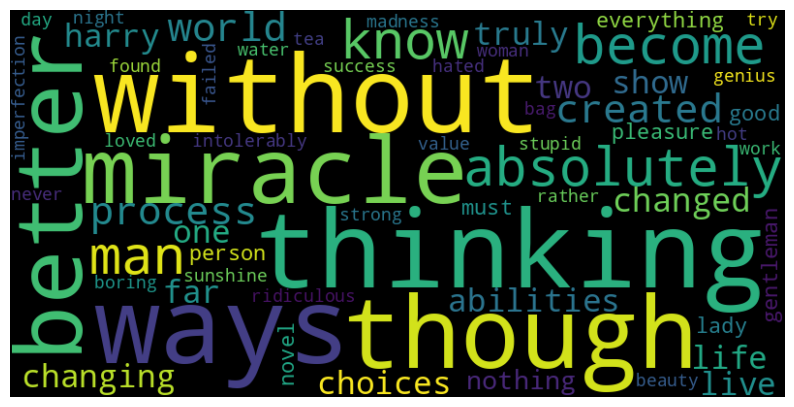

In [23]:
# Generate a word cloud from the word tokens
all_words = ' '.join([' '.join(tokens) for tokens in df['word_tokens'].dropna()])

wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110, stopwords=STOPWORDS).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

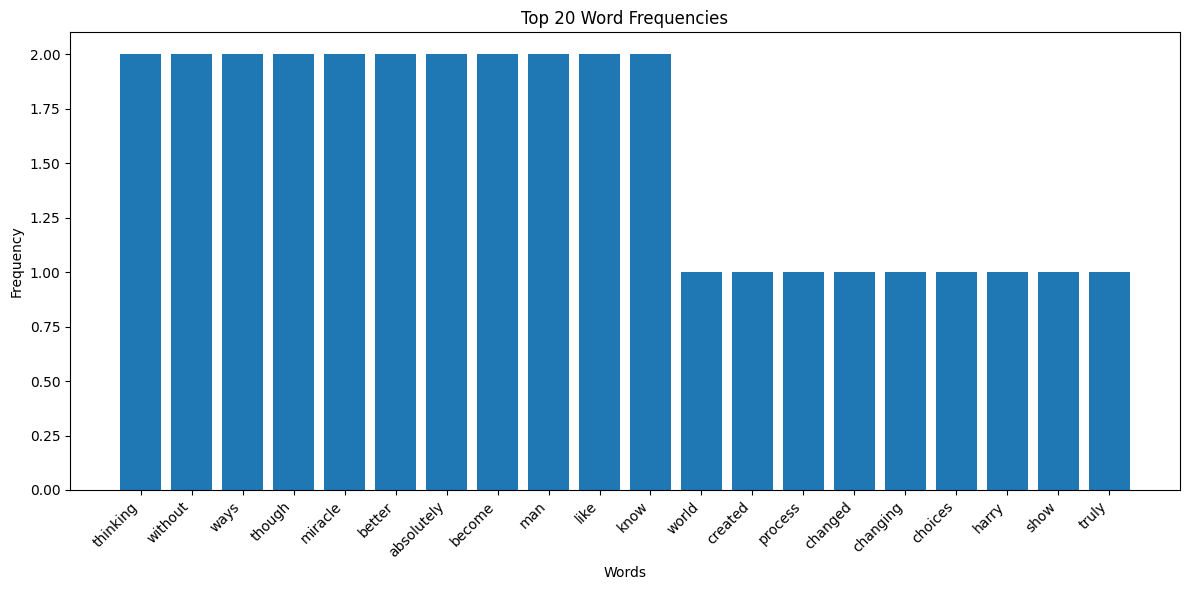

In [24]:
from collections import Counter

# Calculate word frequencies
all_words_list = [word for tokens in df['word_tokens'].dropna() for word in tokens]
word_counts = Counter(all_words_list)

# Get the most common words and their frequencies
most_common_words = word_counts.most_common(20) # Adjust 20 as needed

# Prepare data for plotting
words, frequencies = zip(*most_common_words)

# Create histogram for word frequencies
plt.figure(figsize=(12, 6))
plt.bar(words, frequencies)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Word Frequencies')
plt.tight_layout()
plt.show()

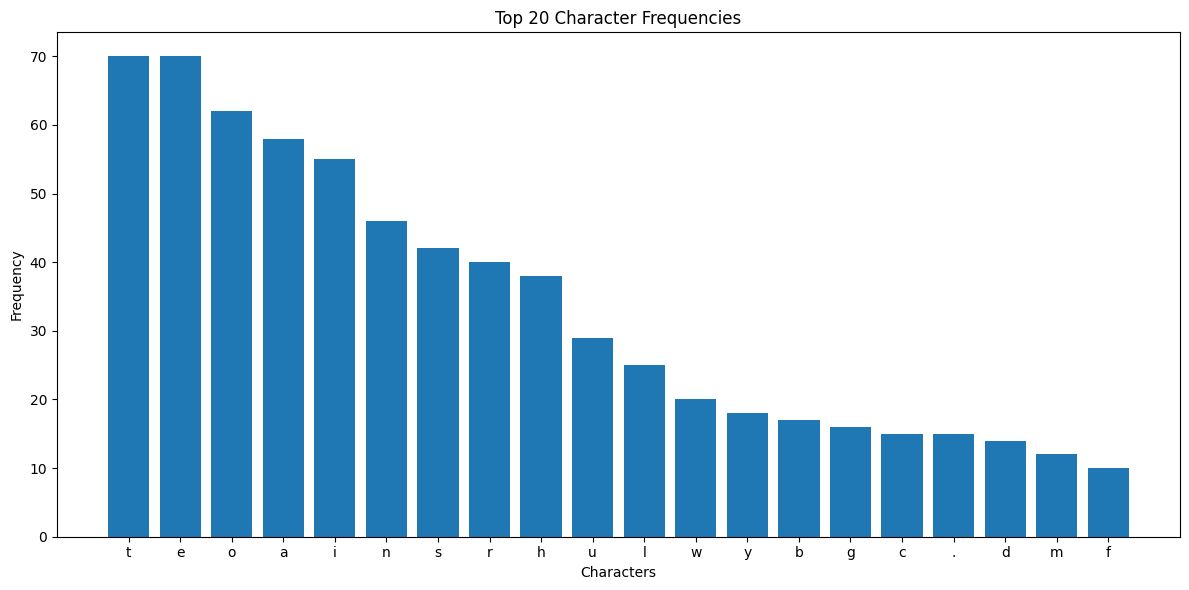

In [25]:
# Calculate character frequencies
all_chars_list = [char for tokens in df['char_tokens'].dropna() for char in tokens]
char_counts = Counter(all_chars_list)

# Get the most common characters and their frequencies
most_common_chars = char_counts.most_common(20) # Adjust 20 as needed

# Prepare data for plotting
chars, char_frequencies = zip(*most_common_chars)

# Create histogram for character frequencies
plt.figure(figsize=(12, 6))
plt.bar(chars, char_frequencies)
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.title('Top 20 Character Frequencies')
plt.tight_layout()
plt.show()



## bigrams, trigrams from the word tokens.


In [26]:
def generate_ngrams(tokens, n):
    """Generates n-grams from a list of tokens."""
    if not tokens or len(tokens) < n:
        return []
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

# Apply the function to create bigrams and trigrams
df['bigrams'] = df['word_tokens'].apply(lambda tokens: generate_ngrams(tokens, 2))
df['trigrams'] = df['word_tokens'].apply(lambda tokens: generate_ngrams(tokens, 3))

# Display the new columns
display(df[['word_tokens', 'bigrams', 'trigrams']].head())

,word_tokens,bigrams,trigrams
0,"[world, created, process, thinking, changed, w...","[(world, created), (created, process), (proces...","[(world, created, process), (created, process,..."
1,"[choices, harry, show, truly, far, abilities]","[(choices, harry), (harry, show), (show, truly...","[(choices, harry, show), (harry, show, truly),..."
2,"[two, ways, live, life, one, though, nothing, ...","[(two, ways), (ways, live), (live, life), (lif...","[(two, ways, live), (ways, live, life), (live,..."
3,"[person, gentleman, lady, pleasure, good, nove...","[(person, gentleman), (gentleman, lady), (lady...","[(person, gentleman, lady), (gentleman, lady, ..."
4,"[imperfection, beauty, madness, genius, better...","[(imperfection, beauty), (beauty, madness), (m...","[(imperfection, beauty, madness), (beauty, mad..."


## Calculate n-gram frequencies


In [27]:
from collections import Counter

# Flatten the lists of bigrams and trigrams
all_bigrams = [bigram for sublist in df['bigrams'].dropna() for bigram in sublist]
all_trigrams = [trigram for sublist in df['trigrams'].dropna() for trigram in sublist]

# Count occurrences
bigram_counts = Counter(all_bigrams)
trigram_counts = Counter(all_trigrams)

# Print the top 20 most common bigrams and trigrams
print("Top 20 Most Common Bigrams:")
for bigram, count in bigram_counts.most_common(20):
    print(f"{bigram}: {count}")

print("\nTop 20 Most Common Trigrams:")
for trigram, count in trigram_counts.most_common(20):
    print(f"{trigram}: {count}")

Top 20 Most Common Bigrams:
('become', 'man'): 2
('world', 'created'): 1
('created', 'process'): 1
('process', 'thinking'): 1
('thinking', 'changed'): 1
('changed', 'without'): 1
('without', 'changing'): 1
('changing', 'thinking'): 1
('choices', 'harry'): 1
('harry', 'show'): 1
('show', 'truly'): 1
('truly', 'far'): 1
('far', 'abilities'): 1
('two', 'ways'): 1
('ways', 'live'): 1
('live', 'life'): 1
('life', 'one'): 1
('one', 'though'): 1
('though', 'nothing'): 1
('nothing', 'miracle'): 1

Top 20 Most Common Trigrams:
('world', 'created', 'process'): 1
('created', 'process', 'thinking'): 1
('process', 'thinking', 'changed'): 1
('thinking', 'changed', 'without'): 1
('changed', 'without', 'changing'): 1
('without', 'changing', 'thinking'): 1
('choices', 'harry', 'show'): 1
('harry', 'show', 'truly'): 1
('show', 'truly', 'far'): 1
('truly', 'far', 'abilities'): 1
('two', 'ways', 'live'): 1
('ways', 'live', 'life'): 1
('live', 'life', 'one'): 1
('life', 'one', 'though'): 1
('one', 'though'

## Visualize n-gram frequencies using a histogram



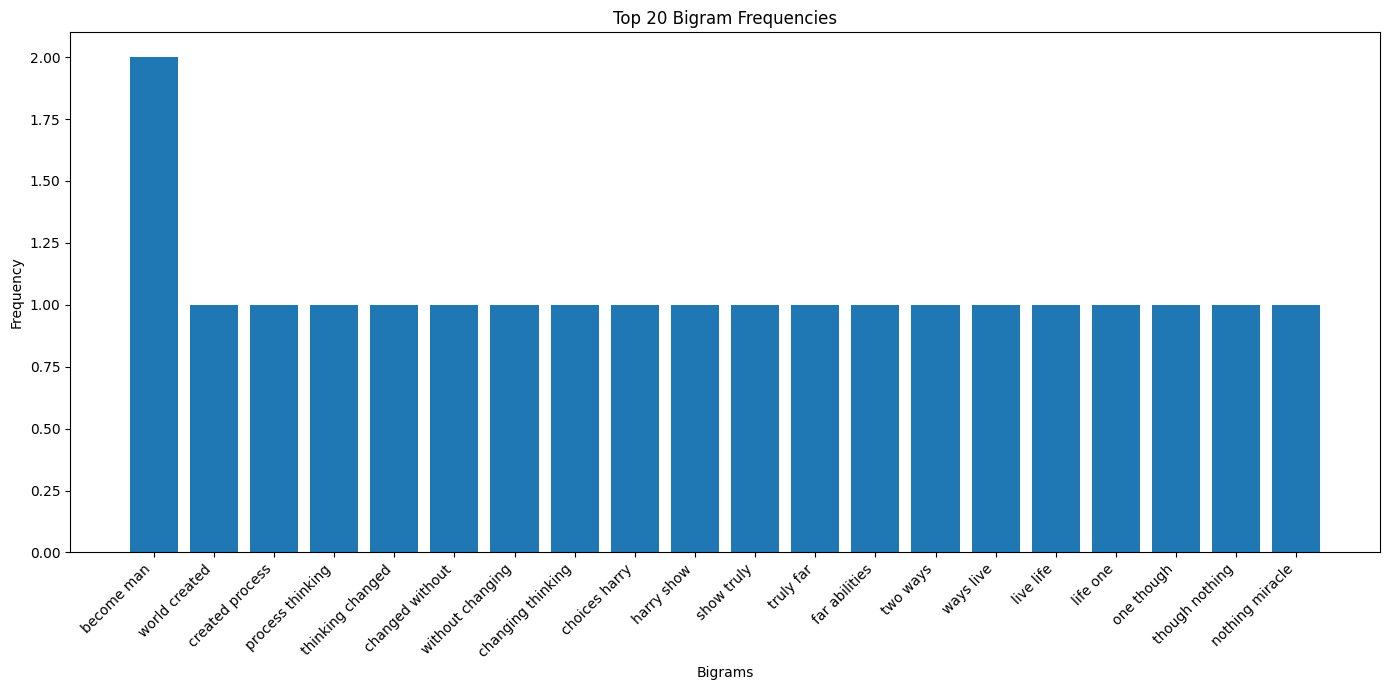

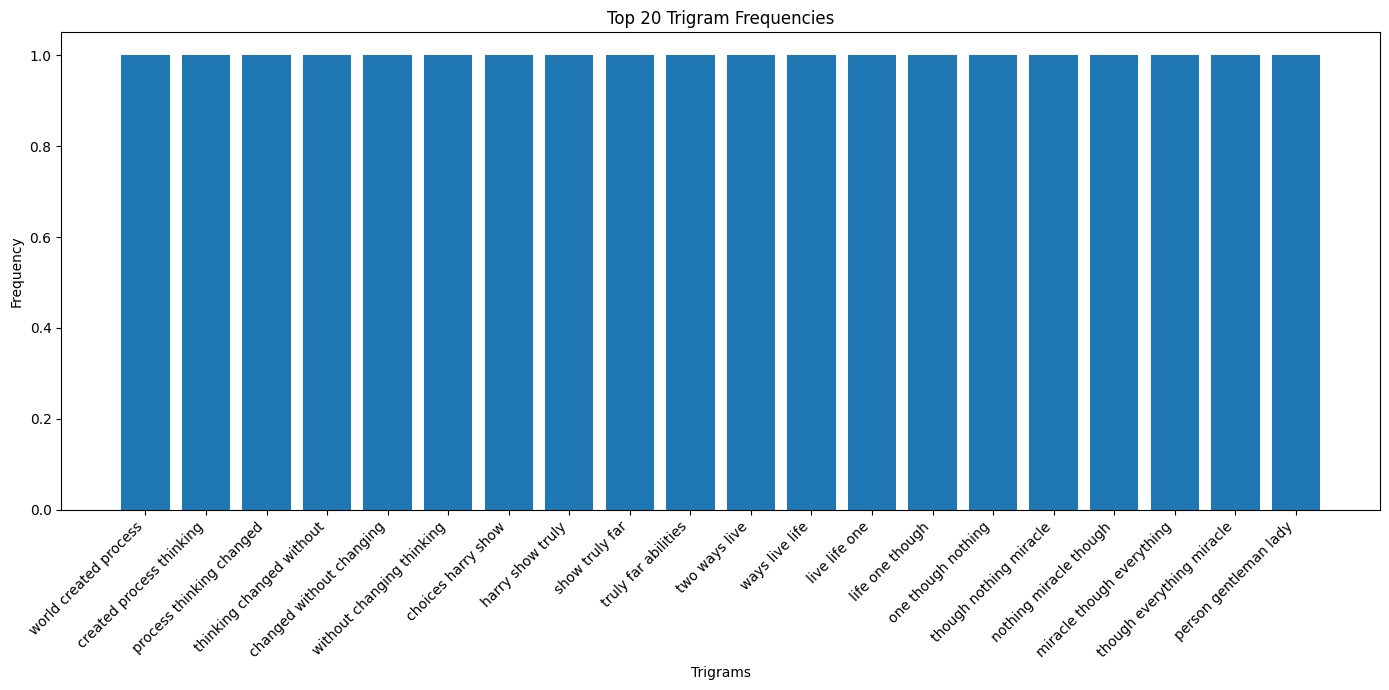

In [28]:
TOP_N = 20

# Get the top N most common bigrams and their frequencies
most_common_bigrams = bigram_counts.most_common(TOP_N)
bigrams, bigram_frequencies = zip(*most_common_bigrams)
bigrams_labels = [' '.join(bigram) for bigram in bigrams] # Join tuples for plotting labels

# Get the top N most common trigrams and their frequencies
most_common_trigrams = trigram_counts.most_common(TOP_N)
trigrams, trigram_frequencies = zip(*most_common_trigrams)
trigrams_labels = [' '.join(trigram) for trigram in trigrams] # Join tuples for plotting labels

# Create bar plot for bigram frequencies
plt.figure(figsize=(14, 7))
plt.bar(bigrams_labels, bigram_frequencies)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.title(f'Top {TOP_N} Bigram Frequencies')
plt.tight_layout()
plt.show()

# Create bar plot for trigram frequencies
plt.figure(figsize=(14, 7))
plt.bar(trigrams_labels, trigram_frequencies)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Trigrams')
plt.ylabel('Frequency')
plt.title(f'Top {TOP_N} Trigram Frequencies')
plt.tight_layout()
plt.show()

## Apply tf-idf
### to understand the importance of words in each document.


In [29]:
# Join tokens back into strings for TF-IDF
df['word_tokens_str'] = df['word_tokens'].apply(lambda tokens: ' '.join(tokens) if tokens else '')

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1000) # You can adjust max_features

# Fit and transform the data
tfidf_matrix = tfidf_vectorizer.fit_transform(df['word_tokens_str'])

# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Display the shape of the TF-IDF matrix
print("Shape of TF-IDF matrix:", tfidf_matrix.shape)

# Optional: Display the TF-IDF values for the first few documents
# You can convert to a dense array and then to a DataFrame for easier viewing
# tfidf_df = pd.DataFrame(tfidf_matrix.todense(), columns=feature_names)
# display(tfidf_df.head())

Shape of TF-IDF matrix: (10, 62)


In [ ]:
# Calculate cosine similarity between words based on TF-IDF
# For a direct word similarity based on TF-IDF, we need to transpose the matrix
tfidf_matrix_T = tfidf_matrix.T

# Calculate cosine similarity between word vectors
word_similarity_matrix = cosine_similarity(tfidf_matrix_T)

# Create a DataFrame for better viewing
word_similarity_df = pd.DataFrame(word_similarity_matrix, index=feature_names, columns=feature_names)

# Display the word similarity matrix (first few rows/columns)
print("Word Similarity Matrix (based on TF-IDF):")
display(word_similarity_df.head())

# Example: Find words most similar to a specific word (e.g., 'thinking')
if 'thinking' in word_similarity_df.columns:
    print("\nWords most similar to 'thinking' (based on TF-IDF):")
    display(word_similarity_df['thinking'].sort_values(ascending=False).head(10))
else:
    print("\n'thinking' not found in the vocabulary.")

Word Similarity Matrix (based on TF-IDF):


,abilities,absolutely,bag,beauty,become,better,boring,changed,changing,choices,...,truly,try,two,value,water,ways,without,woman,work,world
abilities,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
absolutely,0.0,1.0,0.0,1.0,0.0,0.449998,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bag,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
beauty,0.0,1.0,0.0,1.0,0.0,0.449998,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
become,0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0



Words most similar to 'thinking' (based on TF-IDF):


,thinking
world,1.00000
thinking,1.00000
changed,1.00000
changing,1.00000
process,1.00000
created,1.00000
without,0.58912
pleasure,0.00000
show,0.00000
ridiculous,0.00000


In [35]:
# Train a Word2Vec model
# We use the list of word tokens for training
word2vec_model = Word2Vec(sentences=df['word_tokens'].dropna(), vector_size=100, window=5, min_count=1, workers=4)

# Display the vocabulary size
print("Word2Vec model vocabulary size:", len(word2vec_model.wv))

# Save the trained model
model_path = "word2vec_quotes.model"
word2vec_model.save(model_path)
print(f"\nWord2Vec model saved to: {model_path}")

Word2Vec model vocabulary size: 62

Word2Vec model saved to: word2vec_quotes.model


In [36]:
# Load the saved Word2Vec model
model_path = "word2vec_quotes.model"
loaded_word2vec_model = Word2Vec.load(model_path)
print(f"Word2Vec model loaded from: {model_path}")

# Example: Find words most similar to a specific word (e.g., 'thinking') using the loaded model
word_to_find_similarity = 'thinking'

if word_to_find_similarity in loaded_word2vec_model.wv:
    print(f"\nWords most similar to '{word_to_find_similarity}' (based on loaded Word2Vec model):")
    try:
        display(loaded_word2vec_model.wv.most_similar(word_to_find_similarity))
    except KeyError:
        print(f"'{word_to_find_similarity}' not found in loaded Word2Vec vocabulary.")
else:
    print(f"'{word_to_find_similarity}' not found in loaded Word2Vec vocabulary.")

Word2Vec model loaded from: word2vec_quotes.model

Words most similar to 'thinking' (based on loaded Word2Vec model):


[('tea', 0.26953279972076416),
 ('must', 0.14384198188781738),
 ('life', 0.12863658368587494),
 ('person', 0.11039657890796661),
 ('hated', 0.10998903214931488),
 ('man', 0.1097717210650444),
 ('abilities', 0.10884739458560944),
 ('far', 0.10198597609996796),
 ('two', 0.09951357543468475),
 ('pleasure', 0.09631377458572388)]

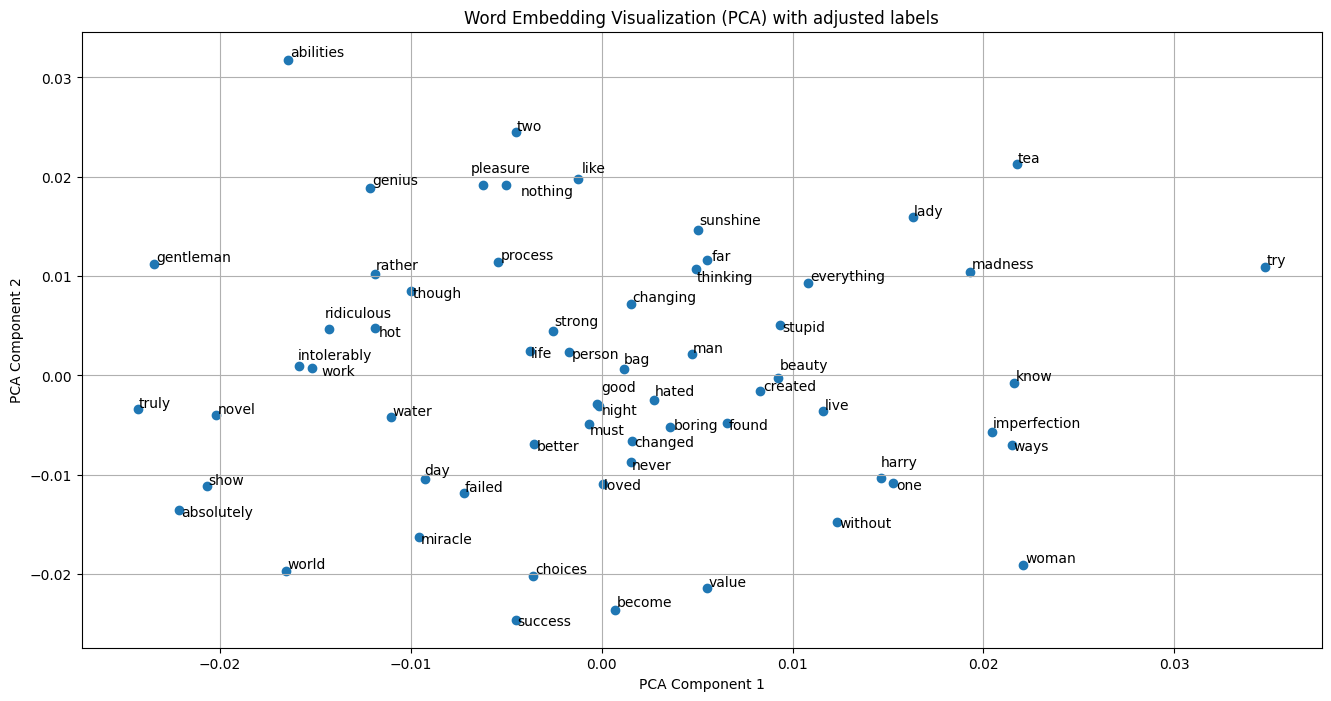

In [40]:
# Visualize Word Embeddings using PCA
# Get the word vectors and corresponding words
words = list(word2vec_model.wv.index_to_key)
vectors = word2vec_model.wv[words]

# Reduce dimensions using PCA to 2 components
pca = PCA(n_components=2)
vectors_pca = pca.fit_transform(vectors)

# Create a DataFrame for the reduced vectors and words
pca_df = pd.DataFrame(vectors_pca, columns=['pca1', 'pca2'])
pca_df['word'] = words

# Plot the word embeddings
plt.figure(figsize=(16, 8))
plt.scatter(pca_df['pca1'], pca_df['pca2'])

# Add annotations using adjustText to avoid overlapping
texts = []
for i, row in pca_df.iterrows():
    texts.append(plt.text(row['pca1'], row['pca2'], row['word']))

from adjustText import adjust_text
adjust_text(texts)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Word Embedding Visualization (PCA) with adjusted labels')
plt.grid(True)
plt.show()

In [34]:
# Load the saved Word2Vec model
model_path = "word2vec_quotes.model"
loaded_word2vec_model = Word2Vec.load(model_path)
print(f"Word2Vec model loaded from: {model_path}")

# Example: Find words most similar to a specific word (e.g., 'thinking') using the loaded model
word_to_find_similarity = 'thinking'

if word_to_find_similarity in loaded_word2vec_model.wv:
    print(f"\nWords most similar to '{word_to_find_similarity}' (based on loaded Word2Vec model):")
    try:
        display(loaded_word2vec_model.wv.most_similar(word_to_find_similarity))
    except KeyError:
        print(f"'{word_to_find_similarity}' not found in loaded Word2Vec vocabulary.")
else:
    print(f"'{word_to_find_similarity}' not found in loaded Word2Vec vocabulary.")

Word2Vec model loaded from: word2vec_quotes.model

Words most similar to 'thinking' (based on loaded Word2Vec model):


[('tea', 0.26953279972076416),
 ('must', 0.14384198188781738),
 ('life', 0.12863658368587494),
 ('person', 0.11039657890796661),
 ('hated', 0.10998903214931488),
 ('man', 0.1097717210650444),
 ('abilities', 0.10884739458560944),
 ('far', 0.10198597609996796),
 ('two', 0.09951357543468475),
 ('pleasure', 0.09631377458572388)]